 # 🌡️ Heat Wave & Cold Snap — Data Preparation Notebook



 **Purpose:**

 Clean and prepare the raw heat wave / cold snap events dataset

 for downstream machine learning use.



 **Objective (reminder):**

 We want a model that outputs *regional probabilities* of heat wave /

 cold snap on a given date, enabling queries like:

 - *"Which NERC region has the lowest heat-wave probability on date X?"*

 - *"If I travel to region Y on date X, what is the likelihood of a heat wave?"*



 **Notebook Structure:**

 ```

 0. Setup & Configuration

 1. Load Data

 2. Initial Inspection

 3. Missing Value Handling

 4. Duplicate Removal

 5. Type Coercion & Categorical Cleanup  ← includes K→°C conversion

 6. Outlier Treatment

 7. Validation & Final Checks

 8. Save Outputs

 ```



 **Inputs:**  `data/raw/data.csv`

 **Outputs:** `data/processed/cleaned.csv`

              `data/processed/cleaning_log.csv`

 ---

 ## 0. Setup & Configuration

In [7]:
# ── Standard library ─────────────────────────────────────────
import warnings
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ── Notebook display settings ─────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)
%matplotlib inline
plt.rcParams.update({
    "figure.dpi":      120,
    "figure.figsize":  (10, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size":       11,
})
sns.set_palette("muted")


 ### 0.1 Reproducibility seed & paths



 All configurable values live here — change the input path or

 thresholds in this single cell; nothing else needs editing.

In [ ]:
# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── File paths (edit INPUT_CSV to point to your file) ─────────
ROOT_DIR     = Path("ESSD_AI_Competition_1/week2")
INPUT_CSV   = ROOT_DIR / "data/combined_extreme_thermal_event_library.csv"
PROC_DIR    = ROOT_DIR / "data/processed"
FIG_DIR     = ROOT_DIR / "figures/data_cleaning"

PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


 ### 0.2 Schema & domain constraints



 All column names, types, valid ranges, and allowed categories

 are defined here as the **single source of truth** for the

 cleaning steps that follow.



 > **Note:** The raw data stores temperature in **Kelvin (K)**.

 > Section 5.7 converts it to **Celsius (°C)**. The configuration

 > below defines constraints for *both* the pre-conversion (K)

 > and post-conversion (°C) stages.

In [9]:
# ── Column groups ──────────────────────────────────────────────
DATE_COLS = ["start_date", "end_date", "centroid_date"]
CAT_COLS  = ["hazard_type", "aggregation_method", "NERC_ID"]
KEY_COLS  = ["hazard_type", "definition_id", "start_date", "NERC_ID"]

# NUM_COLS starts with the original K column;
# updated to °C after conversion in Step 5.7
NUM_COLS  = ["extreme_temperature_K", "duration_days", "spatial_coverage_pct"]

# ── Temperature conversion constants ──────────────────────────
TEMP_COL_K       = "extreme_temperature_K"       # original column name
TEMP_COL_C       = "extreme_temperature_C"       # renamed after conversion
KELVIN_OFFSET    = 273.15                         # K → °C : subtract 273.15

# ── Allowed categorical values (None = no restriction) ────────
ALLOWED_VALUES = {
    "hazard_type":        {"heat_wave", "cold_snap"},
    "aggregation_method": None,
    "NERC_ID":            None,
}

# ── Physical / domain valid ranges ────────────────────────────
# Pre-conversion (K) ranges used during initial inspection & imputation
NUMERIC_RANGES_K = {
    "extreme_temperature_K": (220.0, 330.0),    # ~-53 °C to ~57 °C
    "duration_days":         (1.0,   365.0),
    "spatial_coverage_pct":  (0.0,   100.0),
}

# Post-conversion (°C) ranges used during outlier capping (Step 6)
NUMERIC_RANGES_C = {
    "extreme_temperature_C": (-53.15, 56.85),   # same bounds, in °C
    "duration_days":         (1.0,    365.0),
    "spatial_coverage_pct":  (0.0,    100.0),
}

# ── Outlier strategy ───────────────────────────────────────────
IQR_MULTIPLIER      = 1.5    # standard Tukey fence

# ── Missing value thresholds ───────────────────────────────────
MISSING_WARN_PCT    = 5.0    # flag columns > 5 % missing
MISSING_DROP_PCT    = 50.0   # drop columns > 50 % missing entirely

# ── Cleaning log — we'll append to this throughout ────────────
cleaning_log: list[dict] = []

def _log(step: str, column: str, action: str, detail: str, n_affected: int):
    """Append one entry to the cleaning audit log."""
    cleaning_log.append({
        "step":       step,
        "column":     column,
        "action":     action,
        "detail":     detail,
        "n_affected": n_affected,
    })
    print(f"  [{step}] {column}: {action} — {detail} (n={n_affected})")

print("✅ Configuration complete.")
print(f"   Input  : {INPUT_CSV}")
print(f"   Output : {PROC_DIR}")
print(f"   Temp conversion: {TEMP_COL_K} → {TEMP_COL_C} (subtract {KELVIN_OFFSET})")


✅ Configuration complete.
   Input  : C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\combined_extreme_thermal_event_library.csv
   Output : C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed
   Temp conversion: extreme_temperature_K → extreme_temperature_C (subtract 273.15)


 ---

 ## 1. Load Data



 We load the raw CSV once and immediately save an untouched

 copy as `original.csv` — the raw file is never modified.

In [65]:
df_raw = pd.read_csv(INPUT_CSV, low_memory=False)

# Save original immediately (immutable audit reference)
df_raw.to_csv(PROC_DIR / "data_raw.csv", index=False)

print(f"Loaded  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns : {list(df_raw.columns)}")


Loaded  : 183,791 rows × 10 columns
Columns : ['hazard_type', 'aggregation_method', 'definition_id', 'start_date', 'end_date', 'centroid_date', 'extreme_temperature_K', 'duration_days', 'NERC_ID', 'spatial_coverage_pct']


 ---

 ## 2. Initial Inspection



 Before touching anything we build a **baseline snapshot** so we

 can show before-vs-after comparisons at the end.



 > Temperature is still in Kelvin at this stage — conversion

 > happens in Step 5.7.

 ### 2.1 Data types & sample rows

In [11]:
print("─── Data Types ───────────────────────────────")
print(df_raw.dtypes.to_string())


─── Data Types ───────────────────────────────
hazard_type                  str
aggregation_method           str
definition_id                str
start_date                   str
end_date                     str
centroid_date                str
extreme_temperature_K    float64
duration_days              int64
NERC_ID                      str
spatial_coverage_pct     float64


In [12]:
df_raw.head(10)


,hazard_type,aggregation_method,definition_id,start_date,end_date,centroid_date,extreme_temperature_K,duration_days,NERC_ID,spatial_coverage_pct
0,cold_snap,MWA,Def1,1980-01-22,1980-01-24,1980-01-23,270.2355,3,NERC1,75.0000
1,cold_snap,MWA,Def1,1980-01-26,1980-01-27,1980-01-26,273.1371,2,NERC1,54.5455
2,cold_snap,MWA,Def1,1980-02-08,1980-02-11,1980-02-09,269.5021,4,NERC1,77.2727
3,cold_snap,MWA,Def1,1980-11-16,1980-11-19,1980-11-17,269.3943,4,NERC1,79.5455
4,cold_snap,MWA,Def1,1980-11-25,1980-11-27,1980-11-26,270.0021,3,NERC1,68.1818
5,cold_snap,MWA,Def1,1980-12-08,1980-12-10,1980-12-09,271.0748,3,NERC1,77.2727
6,cold_snap,MWA,Def1,1981-01-18,1981-01-19,1981-01-18,272.1878,2,NERC1,68.1818
7,cold_snap,MWA,Def1,1981-01-31,1981-02-03,1981-02-01,268.9151,4,NERC1,79.5455
8,cold_snap,MWA,Def1,1981-11-30,1981-12-01,1981-12-01,270.7797,2,NERC1,54.5455
9,cold_snap,MWA,Def1,1981-12-23,1981-12-26,1981-12-24,268.9880,4,NERC1,77.2727


 ### 2.2 Summary statistics

In [13]:
print("─── Numeric columns (temperature still in K) ─")
df_raw[NUM_COLS].describe().T


─── Numeric columns (temperature still in K) ─


,count,mean,std,min,25%,50%,75%,max
extreme_temperature_K,183791.0000,283.4415,22.0454,229.5378,263.7601,280.4644,305.5740,317.1997
duration_days,183791.0000,6.1453,7.5429,2.0000,3.0000,4.0000,6.0000,109.0000
spatial_coverage_pct,183791.0000,66.7483,21.0239,0.0000,51.1628,66.4894,84.3750,100.0000


In [14]:
print("─── Categorical columns ──────────────────────")
df_raw[CAT_COLS].describe(include="object").T


─── Categorical columns ──────────────────────


,count,unique,top,freq
hazard_type,183791,2,cold_snap,97487
aggregation_method,183791,3,MWP,61469
NERC_ID,183791,16,NERC2,12568


 ### 2.3 Missing value snapshot

In [15]:
miss_raw = pd.DataFrame({
    "dtype":         df_raw.dtypes,
    "missing_count": df_raw.isnull().sum(),
    "missing_pct":   (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    "unique_values": df_raw.nunique(),
}).sort_values("missing_pct", ascending=False)

miss_raw


,dtype,missing_count,missing_pct,unique_values
hazard_type,str,0,0.0000,2
aggregation_method,str,0,0.0000,3
definition_id,str,0,0.0000,12
start_date,str,0,0.0000,12063
end_date,str,0,0.0000,12166
centroid_date,str,0,0.0000,10949
extreme_temperature_K,float64,0,0.0000,61636
duration_days,int64,0,0.0000,103
NERC_ID,str,0,0.0000,16
spatial_coverage_pct,float64,0,0.0000,2481


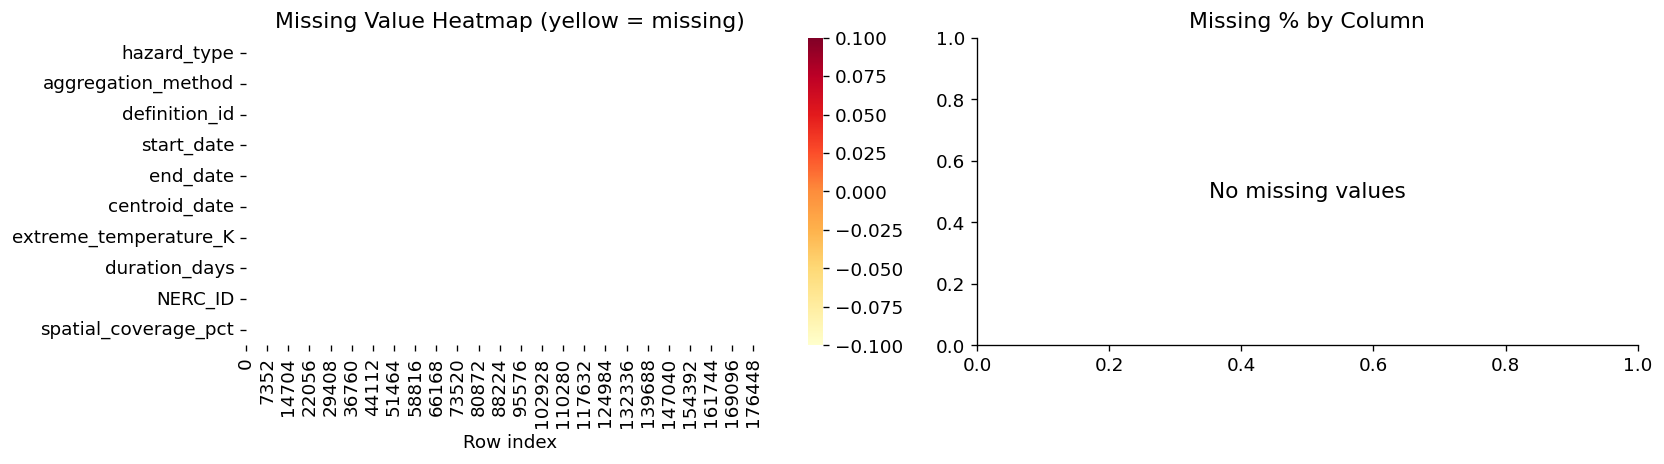

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap
sns.heatmap(
    df_raw.isnull().T,
    cbar=True, cmap="YlOrRd",
    yticklabels=df_raw.columns,
    ax=axes[0],
    linewidths=0.3,
)
axes[0].set_title("Missing Value Heatmap (yellow = missing)")
axes[0].set_xlabel("Row index")

# Bar chart
miss_nonzero = miss_raw[miss_raw["missing_pct"] > 0]
if not miss_nonzero.empty:
    bars = axes[1].barh(
        miss_nonzero.index,
        miss_nonzero["missing_pct"],
        color=["#d73027" if p > MISSING_WARN_PCT else "#fc8d59"
               for p in miss_nonzero["missing_pct"]],
    )
    axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
    axes[1].axvline(
        MISSING_WARN_PCT, color="red", linestyle="--",
        label=f"Warn threshold ({MISSING_WARN_PCT}%)"
    )
    axes[1].set_xlabel("Missing %")
    axes[1].set_title("Missing % by Column")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title("Missing % by Column")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_missing_baseline.png")
plt.show()


 ### 2.4 Class balance

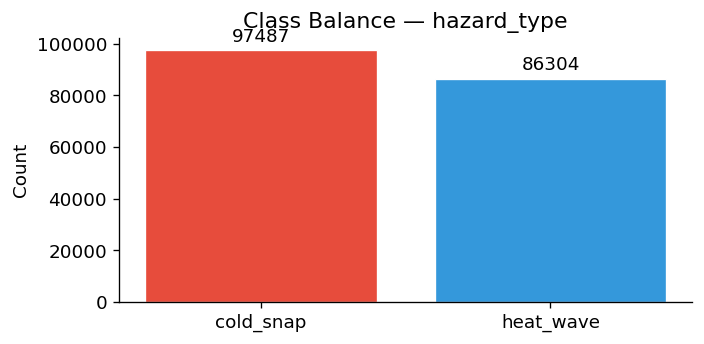

             count     pct
hazard_type               
cold_snap    97487 53.0000
heat_wave    86304 47.0000


In [17]:
if "hazard_type" in df_raw.columns:
    vc = df_raw["hazard_type"].value_counts()
    fig, ax = plt.subplots(figsize=(6, 3))
    bars = ax.bar(vc.index, vc.values, color=["#e74c3c", "#3498db"],
                  edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, padding=3)
    ax.set_title("Class Balance — hazard_type")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_class_balance.png")
    plt.show()
    print(vc.to_frame("count").assign(pct=(vc / vc.sum() * 100).round(1)))


 ### 2.5 Numeric distributions (baseline, temperature in K)

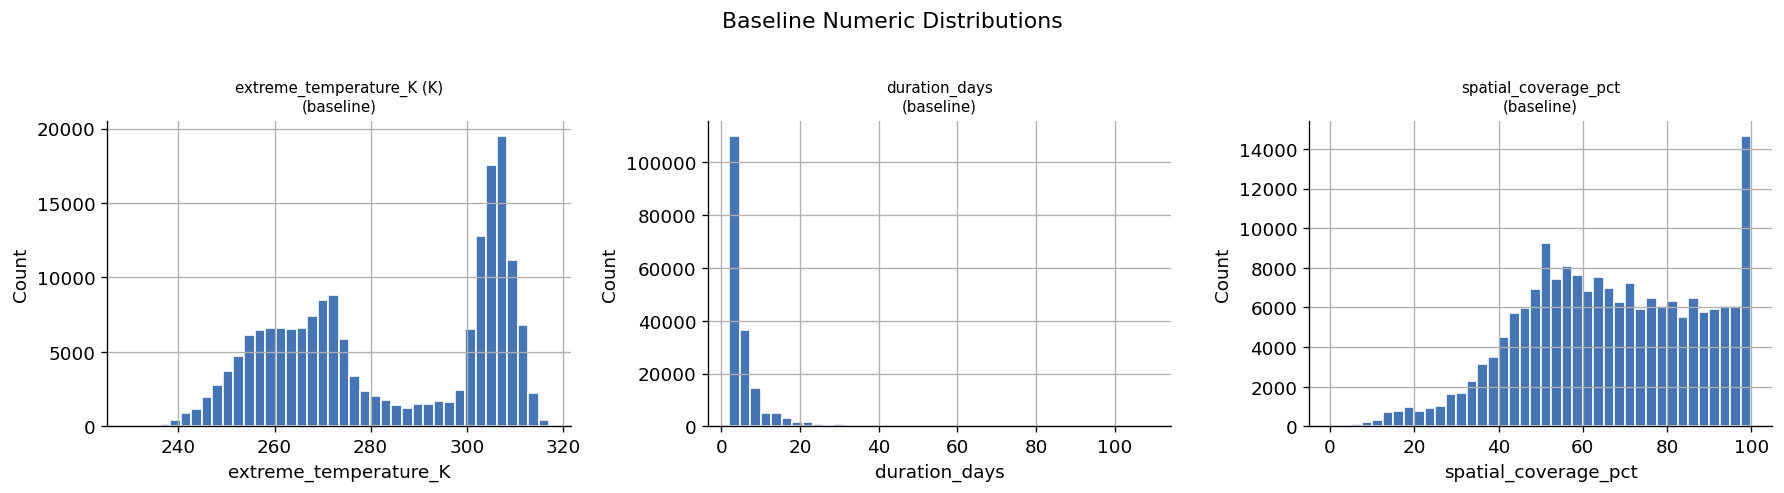

In [18]:
present_num = [c for c in NUM_COLS if c in df_raw.columns]

fig, axes = plt.subplots(1, len(present_num), figsize=(5 * len(present_num), 4))
if len(present_num) == 1:
    axes = [axes]

for ax, col in zip(axes, present_num):
    df_raw[col].dropna().hist(bins=40, ax=ax, color="#4575b4", edgecolor="white")
    unit = " (K)" if "temperature" in col else ""
    ax.set_title(f"{col}{unit}\n(baseline)", fontsize=9)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("Baseline Numeric Distributions", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_numeric_distributions_baseline.png")
plt.show()


 ---

 ## 3. Missing Value Handling



 **Strategy summary:**



 | Column group | Strategy | Rationale |

 |---|---|---|

 | Columns > 50 % missing | **Drop entire column** | More than half the data is absent; imputation would fabricate too much |

 | `start_date`, `centroid_date` | **Drop the row** | These are event anchors — imputing a date would invent an event |

 | Numeric columns | **Group-level median** (NERC × hazard_type), global fallback | Preserves regional and seasonal patterns |

 | Categorical columns | **Fill `'UNKNOWN'`** | Keeps the row; model can learn `'UNKNOWN'` as its own level |

 | Empty strings | **Treat as NaN** | Prevents blank strings entering as a silent category |

In [19]:
# Work on a copy — raw data stays untouched
df = df_raw.copy()


 ### 3.1 Drop columns that are overwhelmingly missing

In [22]:
col_miss_pct = df.isnull().mean() * 100
cols_to_drop = col_miss_pct[col_miss_pct > MISSING_DROP_PCT].index.tolist()

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    for col in cols_to_drop:
        _log("3.1", col, "column dropped",
             f"{col_miss_pct[col]:.1f}% missing > {MISSING_DROP_PCT}% threshold",
             n_affected=int(df_raw[col].isnull().sum()))
    print(f"\n  Dropped {len(cols_to_drop)} column(s): {cols_to_drop}")
else:
    print("No columns exceed the drop threshold "
          f"({MISSING_DROP_PCT}% missing). No columns removed.")


No columns exceed the drop threshold (50.0% missing). No columns removed.


 ### 3.2 Replace empty strings with NaN

In [23]:
for col in df.select_dtypes(include="object").columns:
    mask    = df[col].str.strip().eq("") if df[col].dtype == object else pd.Series(False, index=df.index)
    n_empty = mask.sum()
    if n_empty:
        df.loc[mask, col] = np.nan
        _log("3.2", col, "empty string → NaN",
             "blank / whitespace-only string replaced", n_affected=n_empty)

print("Empty string scan complete.")


Empty string scan complete.


 ### 3.3 Parse date columns



 > `errors='coerce'` converts unparseable values to `NaT`

 > rather than raising an exception — we catch those below.

In [24]:
for col in DATE_COLS:
    if col not in df.columns:
        continue
    before_dtype = df[col].dtype
    df[col] = pd.to_datetime(df[col], errors="coerce")
    n_nat   = df[col].isna().sum()
    print(f"  '{col}': {before_dtype} → {df[col].dtype}  |  NaT count: {n_nat}")
    if n_nat:
        _log("3.3", col, "date parse failure → NaT",
             f"{n_nat} values could not be parsed", n_affected=n_nat)


  'start_date': str → datetime64[us]  |  NaT count: 0
  'end_date': str → datetime64[us]  |  NaT count: 0
  'centroid_date': str → datetime64[us]  |  NaT count: 0


 ### 3.4 Drop rows missing critical anchor dates



 `start_date` and `centroid_date` are the temporal anchors for each

 event. Imputing a date would mean *inventing* when an event happened,

 which is not acceptable. These rows are dropped.

In [26]:
critical_date_cols = [c for c in ["start_date", "centroid_date"]
                      if c in df.columns]
n_before = len(df)
df = df.dropna(subset=critical_date_cols)
n_dropped = n_before - len(df)

if n_dropped:
    _log("3.4", str(critical_date_cols), "row dropped",
         f"missing anchor date(s)", n_affected=n_dropped)
else:
    print(f"No rows dropped — anchor dates present in all rows.")

print(f"Rows remaining: {len(df):,}")


No rows dropped — anchor dates present in all rows.
Rows remaining: 183,791


 ### 3.5 Numeric median imputation



 For each numeric column with missing values:

 1. Compute the median within each **(NERC_ID × hazard_type)** group.

 2. Fill remaining NaN with the **global median** as a fallback.



 Group-level medians are preferred because temperature extremes and

 durations vary substantially by region and hazard type.



 > **Note:** Temperature is still in Kelvin at this stage. The

 > imputed values will be converted to °C together with all other

 > values in Step 5.7.

In [27]:
group_cols = [c for c in ["hazard_type", "NERC_ID"] if c in df.columns]

for col in NUM_COLS:
    if col not in df.columns:
        continue

    df[col] = pd.to_numeric(df[col], errors="coerce")
    n_missing = df[col].isna().sum()

    if n_missing == 0:
        print(f"  '{col}': no missing values — skipped.")
        continue

    # Step 1: group-level median
    group_median = df.groupby(group_cols)[col].transform("median")
    df[col]      = df[col].fillna(group_median)
    n_after_group = df[col].isna().sum()
    n_group_filled = n_missing - n_after_group

    # Step 2: global fallback
    global_med = df[col].median()
    df[col]    = df[col].fillna(global_med)
    n_global_filled = n_after_group

    _log("3.5", col,
         "median imputation",
         f"{n_group_filled} group-median filled "
         f"(groups: {group_cols}); "
         f"{n_global_filled} global-median fallback ({global_med:.4f})",
         n_affected=n_missing)


  'extreme_temperature_K': no missing values — skipped.
  'duration_days': no missing values — skipped.
  'spatial_coverage_pct': no missing values — skipped.


 ### 3.6 Categorical fill with `'UNKNOWN'`

In [28]:
for col in CAT_COLS:
    if col not in df.columns:
        continue
    n_missing = df[col].isna().sum()
    if n_missing:
        df[col] = df[col].fillna("UNKNOWN")
        _log("3.6", col, "filled with UNKNOWN",
             "NaN replaced with sentinel 'UNKNOWN'", n_affected=n_missing)
    else:
        print(f"  '{col}': no missing values — skipped.")


  'hazard_type': no missing values — skipped.
  'aggregation_method': no missing values — skipped.
  'NERC_ID': no missing values — skipped.


 ### 3.7 Verify — zero missing values remaining

In [30]:
remaining_na = df.isnull().sum()
total_na = remaining_na.sum()

if total_na == 0:
    print("All missing values resolved. No NaN remaining.")
else:
    print("Remaining NaN values:")
    print(remaining_na[remaining_na > 0])


All missing values resolved. No NaN remaining.


 ---

 ## 4. Duplicate Removal



 Two types of duplicates are checked in sequence:



 | Type | Detection | Resolution |

 |---|---|---|

 | **Full row** | All columns identical | Drop all but first occurrence |

 | **Logical key** | Same `(hazard_type, definition_id, start_date, NERC_ID)` | Keep row with highest `spatial_coverage_pct` (most representative) |

 ### 4.1 Full row duplicates

In [31]:
n_full_dup = df.duplicated().sum()
print(f"Full row duplicates found: {n_full_dup}")

if n_full_dup:
    display(df[df.duplicated(keep=False)].sort_values(KEY_COLS))
    df = df.drop_duplicates()
    _log("4.1", "ALL COLUMNS", "full-row duplicates dropped",
         f"{n_full_dup} exact duplicate rows removed", n_affected=n_full_dup)
else:
    print("No full row duplicates found.")


Full row duplicates found: 0
No full row duplicates found.


 ### 4.2 Logical / key duplicates

In [33]:
present_keys  = [c for c in KEY_COLS if c in df.columns]
n_before      = len(df)
logical_dupes = df[df.duplicated(subset=present_keys, keep=False)]

print(f"Logical key duplicates found: {len(logical_dupes)} rows")
print(f"Key columns used: {present_keys}")

if len(logical_dupes):
    display(
        logical_dupes
        .sort_values(present_keys)
        .reset_index()
        [present_keys + ["spatial_coverage_pct", TEMP_COL_K]]
    )

    # Keep the observation with the highest spatial coverage
    if "spatial_coverage_pct" in df.columns:
        df = (
            df.sort_values("spatial_coverage_pct", ascending=False)
              .drop_duplicates(subset=present_keys, keep="first")
              .sort_index()
        )
        strategy = "kept highest spatial_coverage_pct"
    else:
        df = df.drop_duplicates(subset=present_keys, keep="first")
        strategy = "kept first occurrence"

    n_removed = n_before - len(df)
    _log("4.2", str(present_keys), "logical duplicates dropped",
         f"{n_removed} rows removed — {strategy}", n_affected=n_removed)
else:
    print("No logical key duplicates found.")

print(f"\nShape after duplicate removal: {df.shape}")


Logical key duplicates found: 0 rows
Key columns used: ['hazard_type', 'definition_id', 'start_date', 'NERC_ID']
No logical key duplicates found.

Shape after duplicate removal: (86128, 10)


 ---

 ## 5. Type Coercion & Categorical Cleanup

 ### 5.1 Standardise categorical strings



 Strip leading/trailing whitespace and lowercase all categorical

 columns to prevent `'Heat_Wave'` and `'heat_wave'` being treated

 as different categories.

In [34]:
for col in CAT_COLS:
    if col not in df.columns:
        continue
    before_unique = df[col].nunique()
    df[col]       = df[col].astype(str).str.strip().str.lower()
    after_unique  = df[col].nunique()
    diff          = before_unique - after_unique

    if diff:
        _log("5.1", col, "string standardisation",
             f"strip + lowercase reduced unique values "
             f"{before_unique} → {after_unique}",
             n_affected=diff)
    else:
        print(f"  '{col}': no change after standardisation "
              f"({after_unique} unique values).")


  'hazard_type': no change after standardisation (2 unique values).
  'aggregation_method': no change after standardisation (3 unique values).
  'NERC_ID': no change after standardisation (16 unique values).


 ### 5.2 Validate `hazard_type` against allowed values

In [35]:
if "hazard_type" in df.columns:
    unexpected = set(df["hazard_type"].unique()) - ALLOWED_VALUES["hazard_type"] - {"unknown"}
    if unexpected:
        n_unexpected = df["hazard_type"].isin(unexpected).sum()
        print(f"Unexpected hazard_type values: {unexpected}")
        df = df[~df["hazard_type"].isin(unexpected)]
        _log("5.2", "hazard_type", "invalid values removed",
             f"Values not in {ALLOWED_VALUES['hazard_type']}: {unexpected}",
             n_affected=n_unexpected)
    else:
        print(f"All hazard_type values are valid: "
              f"{df['hazard_type'].unique()}")


All hazard_type values are valid: <StringArray>
['cold_snap', 'heat_wave']
Length: 2, dtype: str


 ### 5.3 Inspect categorical value counts after cleanup

In [36]:
for col in CAT_COLS:
    if col not in df.columns:
        continue
    vc = df[col].value_counts()
    print(f"\n  ── '{col}' ({vc.shape[0]} unique) ──")
    print(vc.to_frame("count")
           .assign(pct=(vc / vc.sum() * 100).round(1))
           .head(15)
           .to_string())



  ── 'hazard_type' (2 unique) ──
             count     pct
hazard_type               
heat_wave    43546 50.6000
cold_snap    42582 49.4000

  ── 'aggregation_method' (3 unique) ──
                    count     pct
aggregation_method               
mwp                 38940 45.2000
sm                  24344 28.3000
mwa                 22844 26.5000

  ── 'NERC_ID' (16 unique) ──
         count    pct
NERC_ID              
nerc2     6547 7.6000
nerc1     6353 7.4000
nerc4     6125 7.1000
nerc6     5921 6.9000
nerc3     5811 6.7000
nerc15    5618 6.5000
nerc18    5472 6.4000
nerc7     5408 6.3000
nerc9     5193 6.0000
nerc17    5039 5.9000
nerc8     5032 5.8000
nerc5     4991 5.8000
nerc10    4897 5.7000
nerc20    4733 5.5000
nerc11    4533 5.3000


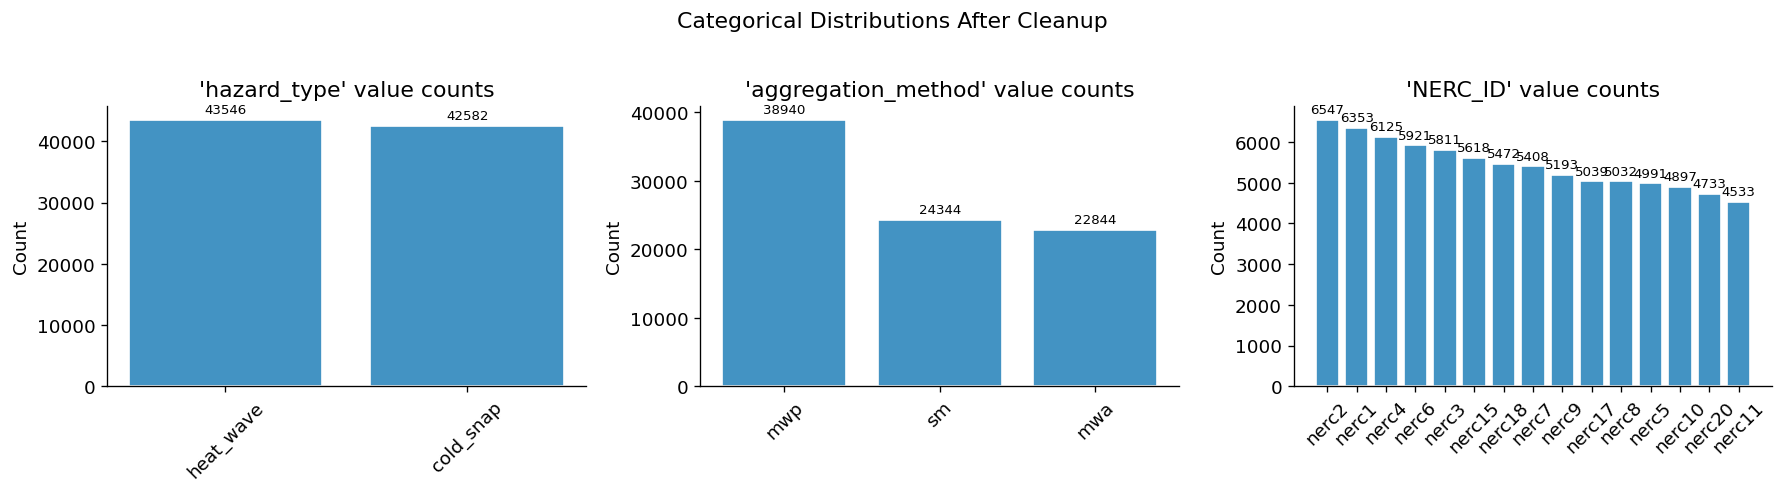

In [37]:
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(5 * len(CAT_COLS), 4))
if len(CAT_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, [c for c in CAT_COLS if c in df.columns]):
    vc = df[col].value_counts().head(15)
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color="#4393c3", edgecolor="white")
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_title(f"'{col}' value counts")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Count")

plt.suptitle("Categorical Distributions After Cleanup", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_categorical_distributions.png")
plt.show()


 ### 5.4 Validate and recompute `duration_days`



 `duration_days` is recomputed from `end_date − start_date + 1`

 as the authoritative source of truth.

 Any mismatch with the original column is flagged before overwriting.

In [38]:
if all(c in df.columns for c in ["start_date", "end_date", "duration_days"]):
    df["_calc_duration"] = (df["end_date"] - df["start_date"]).dt.days + 1
    mismatches           = df["_calc_duration"] != df["duration_days"]
    n_mismatch           = mismatches.sum()

    if n_mismatch:
        print(f"{n_mismatch} rows where reported duration_days ≠ "
              f"computed (end−start+1) — showing first 10:")
        display(
            df.loc[mismatches,
                   ["start_date", "end_date",
                    "duration_days", "_calc_duration"]]
            .head(10)
        )
        _log("5.4", "duration_days", "recomputed from dates",
             f"{n_mismatch} mismatches corrected", n_affected=n_mismatch)
    else:
        print("duration_days is consistent with date difference in all rows.")

    # Always recompute — dates are the source of truth
    df["duration_days"] = df["_calc_duration"]
    df = df.drop(columns=["_calc_duration"])


duration_days is consistent with date difference in all rows.


 ### 5.5 Validate date ordering



 Rules enforced:

 - `start_date ≤ end_date`

 - `start_date ≤ centroid_date ≤ end_date`

In [39]:
rows_dropped_date = []

# Rule 1: start_date <= end_date
if all(c in df.columns for c in ["start_date", "end_date"]):
    bad_order = df["start_date"] > df["end_date"]
    if bad_order.sum():
        print(f"{bad_order.sum()} rows where start_date > end_date → dropped")
        display(df.loc[bad_order, ["start_date", "end_date"]].head(10))
        rows_dropped_date.extend(df.index[bad_order].tolist())
        _log("5.5", "start_date / end_date", "row dropped",
             "start_date > end_date", n_affected=bad_order.sum())
    else:
        print("All rows: start_date ≤ end_date.")

# Rule 2: centroid within [start, end]
if all(c in df.columns for c in DATE_COLS):
    bad_centroid = (
        (df["centroid_date"] < df["start_date"]) |
        (df["centroid_date"] > df["end_date"])
    )
    if bad_centroid.sum():
        print(f"{bad_centroid.sum()} rows where centroid_date is "
              f"outside [start_date, end_date] → dropped")
        display(df.loc[bad_centroid, DATE_COLS].head(10))
        rows_dropped_date.extend(df.index[bad_centroid].tolist())
        _log("5.5", "centroid_date", "row dropped",
             "centroid_date outside [start_date, end_date]",
             n_affected=bad_centroid.sum())
    else:
        print("All rows: centroid_date within [start_date, end_date].")

if rows_dropped_date:
    df = df.drop(index=list(set(rows_dropped_date)))
    df = df.reset_index(drop=True)

print(f"\nShape after date validation: {df.shape}")


All rows: start_date ≤ end_date.
All rows: centroid_date within [start_date, end_date].

Shape after date validation: (86128, 10)


 ### 5.6 Cast numeric columns to `float64`

In [40]:
for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("All numeric columns cast to float64.")
print(df[NUM_COLS].dtypes)


All numeric columns cast to float64.
extreme_temperature_K    float64
duration_days              int64
spatial_coverage_pct     float64
dtype: object


 ### 5.7 🌡️ Convert temperature: Kelvin → Celsius



 The raw data stores extreme temperature in **Kelvin (K)**.

 For interpretability and downstream modelling we convert to

 **degrees Celsius (°C)** using: `T_C = T_K − 273.15`



 After conversion:

 - The column is **renamed** from `extreme_temperature_K` →

   `extreme_temperature_C`.

 - The global `NUM_COLS` list is **updated** so all subsequent steps

   (outlier capping, validation, saving) use the °C column.

In [42]:
if TEMP_COL_K in df.columns:
    # ── Convert ─────────────────────────────────────────────
    df[TEMP_COL_C] = df[TEMP_COL_K] - KELVIN_OFFSET

    # ── Show before / after ─────────────────────────────────
    print("Temperature conversion sample (first 5 rows):")
    print(
        df[[TEMP_COL_K, TEMP_COL_C]].head()
          .to_string(float_format="{:.2f}".format)
    )
    print(f"\nK  range: [{df[TEMP_COL_K].min():.2f}, {df[TEMP_COL_K].max():.2f}]")
    print(f"°C range: [{df[TEMP_COL_C].min():.2f}, {df[TEMP_COL_C].max():.2f}]")

    # ── Drop the original K column ──────────────────────────
    df = df.drop(columns=[TEMP_COL_K])

    # ── Update the global NUM_COLS list ─────────────────────
    NUM_COLS = [TEMP_COL_C if c == TEMP_COL_K else c for c in NUM_COLS]

    _log("5.7", TEMP_COL_K,
         "unit conversion K → °C",
         f"subtracted {KELVIN_OFFSET}; renamed → {TEMP_COL_C}; "
         f"original K column dropped",
         n_affected=len(df))

    print(f"\nColumn renamed: {TEMP_COL_K} → {TEMP_COL_C}")
    print(f"Updated NUM_COLS: {NUM_COLS}")
else:
    print(f"Column '{TEMP_COL_K}' not found — conversion skipped.")


Column 'extreme_temperature_K' not found — conversion skipped.


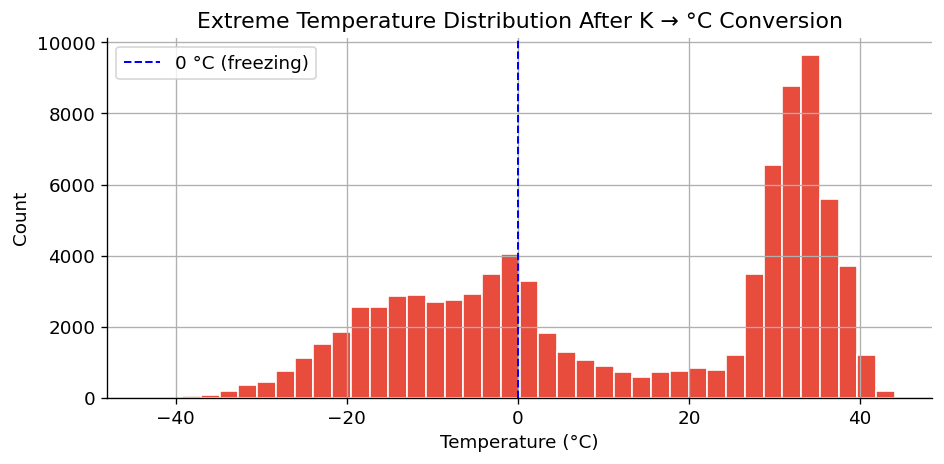

In [43]:
# Quick histogram showing the new °C distribution
if TEMP_COL_C in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    df[TEMP_COL_C].hist(bins=40, ax=ax, color="#e74c3c", edgecolor="white")
    ax.axvline(0, color="blue", linestyle="--", linewidth=1.2,
               label="0 °C (freezing)")
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Count")
    ax.set_title("Extreme Temperature Distribution After K → °C Conversion")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04b_temperature_celsius.png")
    plt.show()


 ---

 ## 6. Outlier Treatment



 ### Strategy: IQR Winsorisation (capping), NOT removal



 > **Why cap instead of remove?**

 > Extreme weather events ARE legitimately extreme by definition —

 > a heat wave that lasts 30 days or reaches 57 °C *should* exist in

 > the dataset. Removing such rows would bias the training data toward

 > mild events and systematically underestimate tail probabilities.

 > Capping limits the statistical *leverage* of erroneous sensor readings

 > while keeping the directional signal.



 **Two-stage process per column:**

 1. Hard clip to **physical bounds** (`NUMERIC_RANGES_C`) — anything

    outside is physically impossible and assumed erroneous.

    Temperature range: −53.15 °C to 56.85 °C.

 2. IQR Winsorisation — cap remaining outliers at

    `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]`.



 > ⚠️ **Leakage note:** In the full ML pipeline these caps will be

 > re-fit on training data only. Here we compute them on the full

 > cleaned dataset for the purposes of data preparation / storage.

 > The saved `cap_stats` dictionary will be used to reproduce the

 > same caps at model training time.

 ### 6.1 Visualise distributions before capping (baseline box plots)

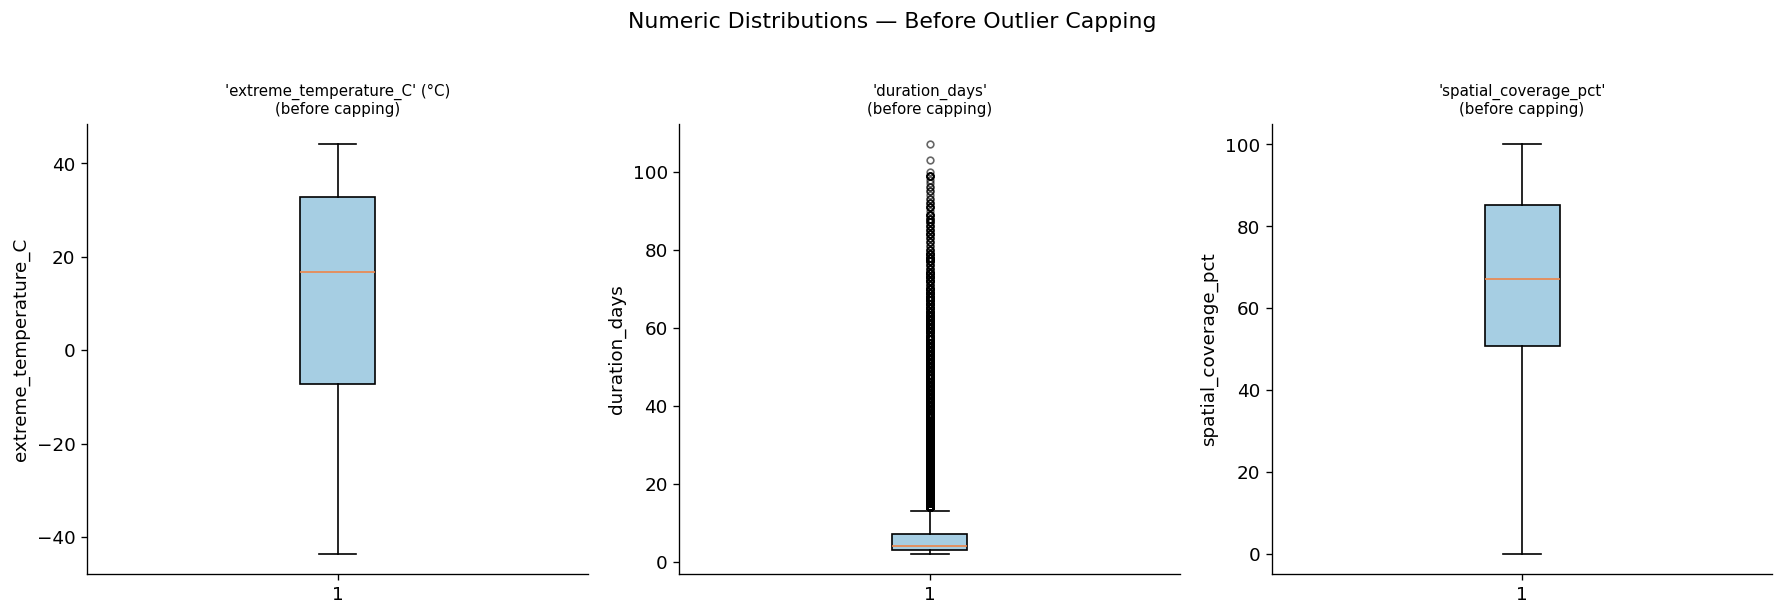

In [44]:
present_num = [c for c in NUM_COLS if c in df.columns]

fig, axes = plt.subplots(1, len(present_num), figsize=(5 * len(present_num), 5))
if len(present_num) == 1:
    axes = [axes]

for ax, col in zip(axes, present_num):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="#a6cee3"),
        flierprops=dict(marker="o", color="red",
                        markersize=4, alpha=0.6),
    )
    unit = " (°C)" if "temperature" in col else ""
    ax.set_title(f"'{col}'{unit}\n(before capping)", fontsize=9)
    ax.set_ylabel(col)

plt.suptitle("Numeric Distributions — Before Outlier Capping", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_boxplots_before_capping.png")
plt.show()


 ### 6.2 Hard clip to physical bounds (using °C ranges)

In [46]:
for col, (lo, hi) in NUMERIC_RANGES_C.items():
    if col not in df.columns:
        continue
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_out:
        df[col] = df[col].clip(lower=lo, upper=hi)
        _log("6.2", col, "hard clip",
             f"physical bounds [{lo}, {hi}]", n_affected=int(n_out))
    else:
        print(f"'{col}': all values within physical bounds [{lo}, {hi}]"
              " — no clip needed.")


'extreme_temperature_C': all values within physical bounds [-53.15, 56.85] — no clip needed.
'duration_days': all values within physical bounds [1.0, 365.0] — no clip needed.
'spatial_coverage_pct': all values within physical bounds [0.0, 100.0] — no clip needed.


 ### 6.3 IQR Winsorisation

In [48]:
cap_stats: dict[str, dict] = {}   # saved for downstream ML pipeline use

for col in present_num:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - IQR_MULTIPLIER * iqr
    hi  = q3 + IQR_MULTIPLIER * iqr

    n_below = (df[col] < lo).sum()
    n_above = (df[col] > hi).sum()
    n_capped = n_below + n_above

    cap_stats[col] = {
        "q1": round(q1, 4), "q3": round(q3, 4), "iqr": round(iqr, 4),
        "iqr_lo": round(lo, 4), "iqr_hi": round(hi, 4),
        "n_capped": int(n_capped),
    }

    df[col] = df[col].clip(lower=lo, upper=hi)

    if n_capped:
        _log("6.3", col, "IQR Winsorisation",
             f"fence=[{lo:.3f}, {hi:.3f}] | "
             f"{n_below} below, {n_above} above",
             n_affected=int(n_capped))
    else:
        print(f"'{col}': no values outside IQR fence "
              f"[{lo:.3f}, {hi:.3f}].")

print("\nCap statistics saved for ML pipeline re-use:")
pd.DataFrame(cap_stats).T


'extreme_temperature_C': no values outside IQR fence [-67.181, 92.842].
'duration_days': no values outside IQR fence [-3.000, 13.000].
'spatial_coverage_pct': no values outside IQR fence [-0.676, 136.799].

Cap statistics saved for ML pipeline re-use:


,q1,q3,iqr,iqr_lo,iqr_hi,n_capped
extreme_temperature_C,-7.1723,32.8335,40.0058,-67.1810,92.8422,0.0000
duration_days,3.0000,7.0000,4.0000,-3.0000,13.0000,0.0000
spatial_coverage_pct,50.8772,85.2459,34.3687,-0.6759,136.7990,0.0000


 ### 6.4 Visualise distributions after capping

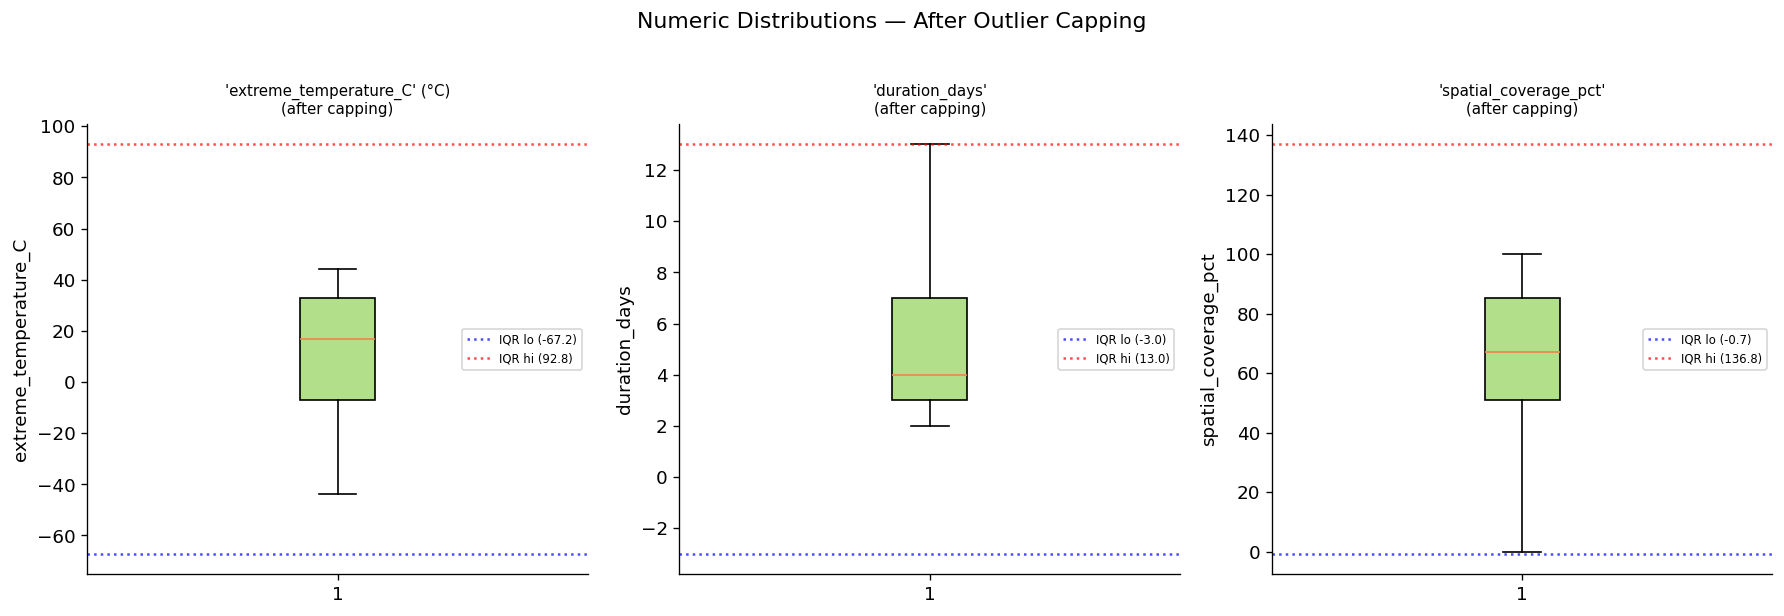

In [49]:
fig, axes = plt.subplots(1, len(present_num), figsize=(5 * len(present_num), 5))
if len(present_num) == 1:
    axes = [axes]

for ax, col in zip(axes, present_num):
    lo = cap_stats[col]["iqr_lo"]
    hi = cap_stats[col]["iqr_hi"]
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor="#b2df8a"),
        flierprops=dict(marker="o", color="orange",
                        markersize=4, alpha=0.6),
    )
    ax.axhline(lo, color="blue", linestyle=":", alpha=0.7,
               label=f"IQR lo ({lo:.1f})")
    ax.axhline(hi, color="red",  linestyle=":", alpha=0.7,
               label=f"IQR hi ({hi:.1f})")
    unit = " (°C)" if "temperature" in col else ""
    ax.set_title(f"'{col}'{unit}\n(after capping)", fontsize=9)
    ax.set_ylabel(col)
    ax.legend(fontsize=7)

plt.suptitle("Numeric Distributions — After Outlier Capping", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_boxplots_after_capping.png")
plt.show()


 ### 6.5 Hazard–temperature alignment check (now in °C)



 Cold snaps should have **lower** temperatures; heat waves should have

 **higher** temperatures. We use **0 °C** as the boundary and flag

 rows where the temperature contradicts the hazard type.

Heat waves with temp < 0.0 °C : 0 rows
Cold snaps with temp > 0.0 °C : 9902 rows

Suspect rows (showing up to 10 each):


,hazard_type,extreme_temperature_C,NERC_ID,start_date
238,cold_snap,0.2143,nerc1,2010-02-03
302,cold_snap,0.2433,nerc1,2019-01-12
463,cold_snap,1.4011,nerc10,1993-01-14
2426,cold_snap,1.9312,nerc2,1980-03-06
2427,cold_snap,1.4110,nerc2,1980-03-25
2431,cold_snap,1.9716,nerc2,1981-02-04
2433,cold_snap,1.0039,nerc2,1981-11-25
2456,cold_snap,0.7555,nerc2,1984-02-10
2498,cold_snap,1.7274,nerc2,1991-01-05
2499,cold_snap,1.1321,nerc2,1991-01-26


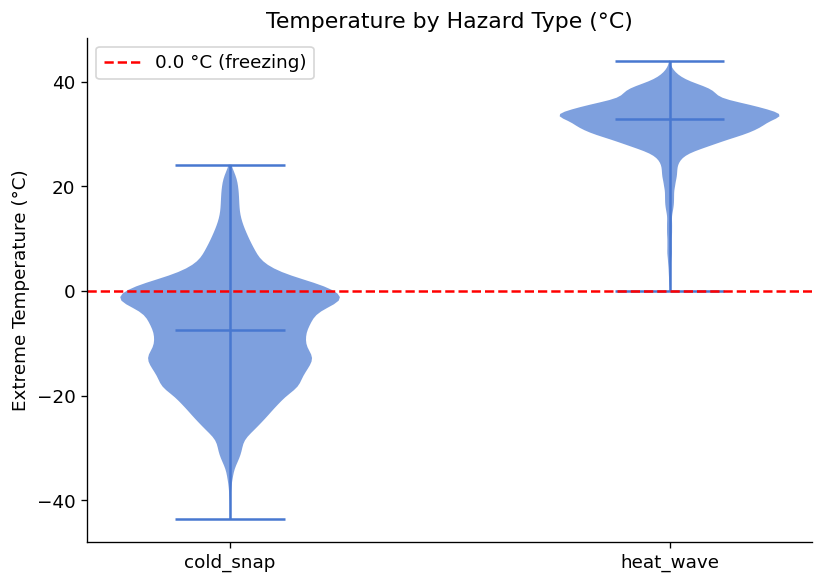

In [50]:
FREEZE_C = 0.0    # 0 °C = freezing point (was 273.15 K before conversion)

if all(c in df.columns for c in ["hazard_type", TEMP_COL_C]):
    suspect_heat = df[
        (df["hazard_type"] == "heat_wave") &
        (df[TEMP_COL_C] < FREEZE_C)
    ]
    suspect_cold = df[
        (df["hazard_type"] == "cold_snap") &
        (df[TEMP_COL_C] > FREEZE_C)
    ]

    print(f"Heat waves with temp < {FREEZE_C} °C : {len(suspect_heat)} rows")
    print(f"Cold snaps with temp > {FREEZE_C} °C : {len(suspect_cold)} rows")

    if len(suspect_heat) or len(suspect_cold):
        print("\nSuspect rows (showing up to 10 each):")
        if len(suspect_heat):
            display(suspect_heat[["hazard_type", TEMP_COL_C,
                                   "NERC_ID", "start_date"]].head(10))
        if len(suspect_cold):
            display(suspect_cold[["hazard_type", TEMP_COL_C,
                                   "NERC_ID", "start_date"]].head(10))
    else:
        print("All temperatures are consistent with their hazard type.")

# Violin plot (°C)
if "hazard_type" in df.columns and TEMP_COL_C in df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    groups = [
        df.loc[df["hazard_type"] == h, TEMP_COL_C].dropna().values
        for h in sorted(df["hazard_type"].unique())
    ]
    labels = sorted(df["hazard_type"].unique())
    parts  = ax.violinplot(groups, showmedians=True)
    for pc in parts["bodies"]:
        pc.set_alpha(0.7)
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.axhline(FREEZE_C, color="red", linestyle="--",
               label=f"{FREEZE_C} °C (freezing)")
    ax.set_ylabel("Extreme Temperature (°C)")
    ax.set_title("Temperature by Hazard Type (°C)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_temp_by_hazard_violin.png")
    plt.show()


 ---

 ## 7. Validation & Final Checks



 A final pass to confirm the cleaned dataset meets all quality

 criteria before saving.

 ### 7.1 Before vs. after summary

In [51]:
summary = pd.DataFrame({
    "Metric": [
        "Row count",
        "Column count",
        "Total missing values",
        "Full row duplicates",
        "Temperature unit",
    ],
    "Before": [
        len(df_raw),
        len(df_raw.columns),
        int(df_raw.isnull().sum().sum()),
        int(df_raw.duplicated().sum()),
        "Kelvin (K)",
    ],
    "After": [
        len(df),
        len(df.columns),
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        "Celsius (°C)",
    ],
})
print(summary.to_string(index=False))


              Metric     Before        After
           Row count     183791        86128
        Column count         10           10
Total missing values          0            0
 Full row duplicates          0            0
    Temperature unit Kelvin (K) Celsius (°C)


 ### 7.2 Final missing value confirmation

In [52]:
final_na = df.isnull().sum()
if final_na.sum() == 0:
    print("Zero missing values in cleaned dataset.")
else:
    print("Remaining missing values:")
    print(final_na[final_na > 0])


Zero missing values in cleaned dataset.


 ### 7.3 Final data types

In [53]:
print(df.dtypes)


hazard_type                         str
aggregation_method                  str
definition_id                       str
start_date               datetime64[us]
end_date                 datetime64[us]
centroid_date            datetime64[us]
duration_days                     int64
NERC_ID                             str
spatial_coverage_pct            float64
extreme_temperature_C           float64
dtype: object


 ### 7.4 Verify temperature column is in Celsius

In [54]:
assert TEMP_COL_C in df.columns, f"Expected '{TEMP_COL_C}' column not found!"
assert TEMP_COL_K not in df.columns, f"Old '{TEMP_COL_K}' column should have been dropped!"

print(f"Temperature column: '{TEMP_COL_C}'")
print(f"Range: [{df[TEMP_COL_C].min():.2f} °C, {df[TEMP_COL_C].max():.2f} °C]")
print(f"Mean:  {df[TEMP_COL_C].mean():.2f} °C")
print(f"Median:{df[TEMP_COL_C].median():.2f} °C")


Temperature column: 'extreme_temperature_C'
Range: [-43.61 °C, 44.05 °C]
Mean:  12.26 °C
Median:16.72 °C


 ### 7.5 Final numeric summary statistics (in °C)

In [55]:
df[NUM_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
extreme_temperature_C,86128.0000,12.2575,21.6761,-43.6122,-7.1723,16.7248,32.8335,44.0497
duration_days,86128.0000,5.2456,3.4831,2.0000,3.0000,4.0000,7.0000,13.0000
spatial_coverage_pct,86128.0000,66.8309,21.7244,0.0000,50.8772,67.2131,85.2459,100.0000


 ### 7.6 Final categorical value counts

In [56]:
for col in CAT_COLS:
    if col in df.columns:
        vc = df[col].value_counts()
        print(f"\n── '{col}' ──")
        print(vc.to_frame("count")
               .assign(pct=(vc / vc.sum() * 100).round(1))
               .to_string())



── 'hazard_type' ──
             count     pct
hazard_type               
heat_wave    43546 50.6000
cold_snap    42582 49.4000

── 'aggregation_method' ──
                    count     pct
aggregation_method               
mwp                 38940 45.2000
sm                  24344 28.3000
mwa                 22844 26.5000

── 'NERC_ID' ──
         count    pct
NERC_ID              
nerc2     6547 7.6000
nerc1     6353 7.4000
nerc4     6125 7.1000
nerc6     5921 6.9000
nerc3     5811 6.7000
nerc15    5618 6.5000
nerc18    5472 6.4000
nerc7     5408 6.3000
nerc9     5193 6.0000
nerc17    5039 5.9000
nerc8     5032 5.8000
nerc5     4991 5.8000
nerc10    4897 5.7000
nerc20    4733 5.5000
nerc11    4533 5.3000
nerc12    4455 5.2000


 ### 7.7 Cross-column consistency

In [57]:
# Single-day events: start_date must equal end_date
if all(c in df.columns for c in ["duration_days", "start_date", "end_date"]):
    single = df[df["duration_days"] == 1]
    bad    = single[single["start_date"] != single["end_date"]]
    print(f"Single-day events (duration=1): {len(single):,}")
    if len(bad):
        print(f"{len(bad)} single-day events where start ≠ end:")
        display(bad[["start_date", "end_date", "duration_days"]].head())
    else:
        print("All single-day events: start_date == end_date.")


Single-day events (duration=1): 0
All single-day events: start_date == end_date.


In [58]:
# Low coverage + long duration: flag for review (not removed)
if all(c in df.columns for c in ["spatial_coverage_pct", "duration_days"]):
    LOW_COV   = 5.0
    LONG_DUR  = 7
    suspect   = df[
        (df["spatial_coverage_pct"] < LOW_COV) &
        (df["duration_days"]        > LONG_DUR)
    ]
    print(f"\nLow coverage (<{LOW_COV}%) + long duration (>{LONG_DUR}d): "
          f"{len(suspect)} rows flagged for review.")
    if len(suspect):
        display(suspect[["NERC_ID", "hazard_type", "spatial_coverage_pct",
                           "duration_days", "start_date"]].head(10))



Low coverage (<5.0%) + long duration (>7d): 54 rows flagged for review.


,NERC_ID,hazard_type,spatial_coverage_pct,duration_days,start_date
54059,nerc11,cold_snap,2.4793,13,1996-01-19
103955,nerc3,heat_wave,3.1915,13,1996-06-19
103980,nerc3,heat_wave,4.2553,13,2009-06-10
116085,nerc10,heat_wave,2.4793,13,1986-06-30
116146,nerc10,heat_wave,2.4793,13,2007-07-16
116149,nerc10,heat_wave,0.8264,13,2008-07-07
117396,nerc4,heat_wave,0.0000,13,1999-07-05
117484,nerc4,heat_wave,0.0000,13,2020-07-08
117586,nerc5,heat_wave,1.4925,13,2007-07-04
117882,nerc8,heat_wave,0.0000,13,2002-07-05


 ### 7.8 Final column listing

In [59]:
print("Final columns in cleaned dataset:")
for i, col in enumerate(df.columns, 1):
    unit = ""
    if col == TEMP_COL_C:
        unit = " ← (converted from K)"
    print(f"  {i:2d}. {col}{unit}")


Final columns in cleaned dataset:
   1. hazard_type
   2. aggregation_method
   3. definition_id
   4. start_date
   5. end_date
   6. centroid_date
   7. duration_days
   8. NERC_ID
   9. spatial_coverage_pct
  10. extreme_temperature_C ← (converted from K)


 ---

 ## 8. Save Outputs

 ### 8.1 Save cleaned dataset

In [61]:
cleaned_path = PROC_DIR / "data_cleaned.csv"
df.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved → {cleaned_path}")
print(f"Shape: {df.shape}")


Cleaned dataset saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\data_cleaned.csv
Shape: (86128, 10)


 ### 8.2 Save cleaning audit log

In [62]:
log_df = pd.DataFrame(cleaning_log)
log_path = PROC_DIR / "cleaning_log.csv"
log_df.to_csv(log_path, index=False)
print(f"Cleaning log saved → {log_path}")
display(log_df)


Cleaning log saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\cleaning_log.csv


,step,column,action,detail,n_affected
0,4.2,"['hazard_type', 'definition_id', 'start_date',...",logical duplicates dropped,97663 rows removed — kept highest spatial_cove...,97663
1,5.7,extreme_temperature_K,unit conversion K → °C,subtracted 273.15; renamed → extreme_temperatu...,86128
2,6.3,duration_days,IQR Winsorisation,"fence=[-3.000, 13.000] | 0 below, 7609 above",7609


 ### 8.3 Save cap statistics (for ML pipeline re-use)

In [63]:
cap_df   = pd.DataFrame(cap_stats).T.reset_index().rename(columns={"index": "column"})
cap_path = PROC_DIR / "outlier_cap_stats.csv"
cap_df.to_csv(cap_path, index=False)
print(f"Cap statistics saved → {cap_path}")
display(cap_df)


Cap statistics saved → C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed\outlier_cap_stats.csv


,column,q1,q3,iqr,iqr_lo,iqr_hi,n_capped
0,extreme_temperature_C,-7.1723,32.8335,40.0058,-67.1810,92.8422,0.0000
1,duration_days,3.0000,7.0000,4.0000,-3.0000,13.0000,0.0000
2,spatial_coverage_pct,50.8772,85.2459,34.3687,-0.6759,136.7990,0.0000


 ### 8.4 Final output summary

In [66]:
print("─" * 55)
print("  DATA PREPARATION COMPLETE")
print("─" * 55)
print(f"  Input rows        : {len(df_raw):>8,}")
print(f"  Output rows       : {len(df):>8,}")
print(f"  Rows removed      : {len(df_raw) - len(df):>8,}")
print(f"  Output columns    : {len(df.columns):>8}")
print(f"  Missing values    : {df.isnull().sum().sum():>8}")
print(f"  Duplicate rows    : {df.duplicated().sum():>8}")
print(f"  Temperature unit  : {'°C':>8}")
print()
print("  Saved files:")
print(f"    {PROC_DIR}/data_raw.csv")
print(f"    {PROC_DIR}/data_cleaned.csv")
print(f"    {PROC_DIR}/cleaning_log.csv")
print(f"    {PROC_DIR}/outlier_cap_stats.csv")
print(f"  Figures in: {FIG_DIR}/")
print("─" * 55)

───────────────────────────────────────────────────────
  DATA PREPARATION COMPLETE
───────────────────────────────────────────────────────
  Input rows        :  183,791
  Output rows       :   86,128
  Rows removed      :   97,663
  Output columns    :       10
  Missing values    :        0
  Duplicate rows    :        0
  Temperature unit  :       °C

  Saved files:
    C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/data_raw.csv
    C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/data_cleaned.csv
    C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/cleaning_log.csv
    C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\processed/outlier_cap_stats.csv
  Figures in: C:\WorkSpace\Tools\AI-ML\ESSD_AI_Competition\week2\data\figures/
───────────────────────────────────────────────────────
